In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
import re

In [2]:
data = pickle.load(open('summary.pkl', 'rb'))

for key in data.keys():
    print(key)


Ours
no_curriculum
example_reward
env_reward
no_refinement


In [3]:
curriculum_results = data['Ours']
scratch_results = data['no_curriculum']
example_results = data['example_reward']
env_results = data['env_reward']
no_refine_results = data['no_refinement']

In [4]:
print(curriculum_results.keys())

dict_keys(['raw', 'mean', 'std'])


In [5]:
# Print out the results for verification
for key, value in data.items():
    for sub_key, sub_value in value.items():
        if sub_key == 'raw':
            print(f"{key} - {sub_key}: {sub_value[:, -1]}")

Ours - raw: [88. 96. 96. 76.]
no_curriculum - raw: [ 0.  0. 24.  0.]
example_reward - raw: [12.  4.  4.  4. 12.]
env_reward - raw: [0. 0. 0. 4. 0.]
no_refinement - raw: [ 0. 76.  0.  0.]


In [6]:
# Plot the success rates
plt.rcParams["font.family"] = "P052" 
plt.rcParams['pdf.fonttype'] = 42  # Use TrueType
plt.rcParams['ps.fonttype'] = 42
curriculum_color = "#1f77b4"  # Blue
scratch_color = "#ff7f0e"     # Orange
no_refine_color = "#2ca02c"   # Green
example_color = "#d62728"     # Red
mqe_color = "#9467bd"         # Purple

x = np.arange(curriculum_results['mean'].shape[0] + 1) * 19200

In [7]:
# Plot the average success rate with shaded std
def plot_with_std(ax, x, mean_curve, std_curve, label, color):    
    # Append 0 in the beginning of mean_curve and std_curve
    mean_curve = np.insert(mean_curve, 0, 0)
    std_curve = np.insert(std_curve, 0, 0)
    ax.plot(x, mean_curve, label=label, color=color, linewidth=3)
    ax.fill_between(x, mean_curve - std_curve, mean_curve + std_curve, color=color, alpha=0.1)

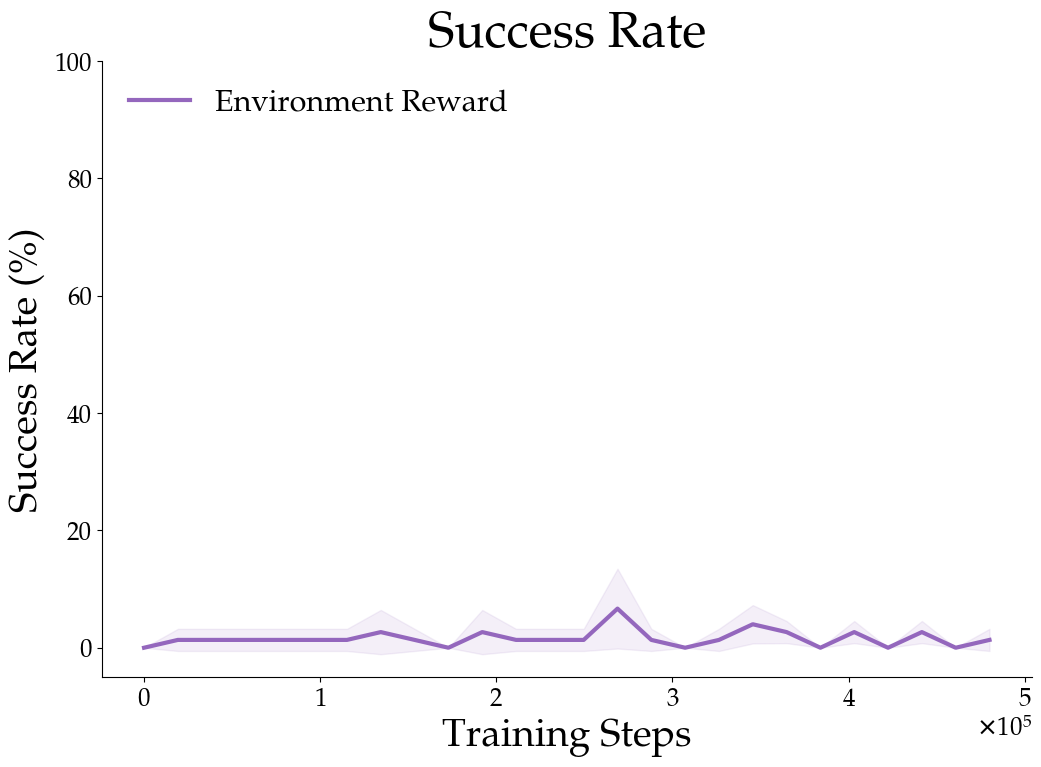

In [ ]:
import matplotlib.ticker as ticker

plt.figure(figsize=(12, 8))

plot_with_std(plt.gca(), x, curriculum_results['mean'], curriculum_results['std'], "CRAFT", curriculum_color)
# plot_with_std(plt.gca(), x, scratch_results['mean'], scratch_results['std'], "No Curriculum", scratch_color)
# plot_with_std(plt.gca(), x, no_refine_results['mean'], no_refine_results['std'], "No Refine", no_refine_color)
# plot_with_std(plt.gca(), x, example_results['mean'], example_results['std'], "Example Reward", example_color)
plot_with_std(plt.gca(), x, env_results['mean'], env_results['std'], "Environment Reward", mqe_color)
plt.title("Success Rate", fontsize=36)
plt.xlabel("Training Steps", fontsize=28)
plt.ylabel("Success Rate (%)", fontsize=28)
plt.tick_params(axis='both', which='both', labelsize=18)
plt.ylim(-5, 100)

plt.legend(frameon=False, loc="upper left", fontsize=22)
plt.grid(False)
# Remove edge lines in right and upper side
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().xaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
plt.gca().ticklabel_format(style='scientific', axis='x', scilimits=(0,0))
plt.gca().xaxis.offsetText.set_fontsize(18)
plt.savefig("figure/lift_total_success_rate.pdf", bbox_inches='tight', dpi=300)
plt.show()